## Notebook Summary

This notebook aims to train a Graph Neural Network (GNN) model to predict code vulnerability in the CWE-77 dataset.

**Current Status:**

1.  **Data Acquisition:** The FUNDED_NISL repository was cloned, and the CWE-77 dataset was unzipped.
2.  **Data Loading and Initial Exploration:** The individual files within the `CWE-77/5result/` directory were loaded into a pandas DataFrame. It was determined that each file represents a single data entry containing a label and graph representation.
3.  **Graph Representation Parsing:** A function was implemented to parse the graph representation from the file contents, extracting edges (specifically, 'children' edges) and raw node features.
4.  **Compact Abstract Graph (CAG) Conversion:** The extracted edges and raw node features were converted into a Compact Abstract Graph (CAG) representation using PyTorch Geometric `Data` objects. This involved mapping the primary AST node types from the raw features to numerical labels as node features.
5.  **GNN Model Definition:** A GCN model with three convolutional layers, global mean pooling, and a linear classifier was defined using PyTorch Geometric.
6.  **Data Splitting:** The dataset of CAGs was split into training (80%) and testing (20%) sets.
7.  **Model Training:** The GCN model was trained for 30 epochs using the Adam optimizer and BCEWithLogitsLoss. The training and test losses were monitored.
8.  **Model Evaluation:** The trained model was evaluated on the test set, achieving a test accuracy of approximately 49.65%.
9.  **Prediction:** The model was used to make predictions on a few sample graphs from the test set.
10. **Analysis and Exploration:**
    *   The process of converting raw node features to numerical CAG node representations was explained, including the AST type mapping.
    *   Approaches for visualizing CAGs using NetworkX and Matplotlib were discussed and a few sample graphs were visualized.
    *   The concept of fairness in code vulnerability detection was analyzed, discussing potential biases and how performance metrics could be used across subgroups, while also noting the limitation of the current dataset for a data-driven fairness analysis due to the lack of subgroup information.

**Next Steps (Planned/Potential):**

*   Improve the GNN model's performance through hyperparameter tuning, exploring different architectures, or increasing training epochs.
*   Investigate the class distribution to address potential class imbalance.
*   Explore richer node feature representations beyond basic AST types.
*   Employ more advanced graph visualization techniques for larger and complex graphs.
*   If possible, augment the dataset with relevant subgroup information to enable a comprehensive fairness analysis.

In [ ]:
!git clone https://github.com/HuantWang/FUNDED_NISL

Cloning into 'FUNDED_NISL'...
remote: Enumerating objects: 12122, done.
remote: Counting objects: 100% (4248/4248), done.
remote: Compressing objects: 100% (1259/1259), done.
remote: Total 12122 (delta 3028), reused 4170 (delta 2974), pack-reused 7874 (from 1)
Receiving objects: 100% (12122/12122), 130.82 MiB | 35.38 MiB/s, done.
Resolving deltas: 100% (6434/6434), done.


**Reasoning**:
Confirm that the repository has been successfully cloned by listing the contents of the current directory.



## Load the data

### Subtask:
Load the dataset into a pandas DataFrame.


**Reasoning**:
Load the dataset into a pandas DataFrame and display the first few rows.



In [ ]:
!unzip /content/FUNDED_NISL/FUNDED/data/data/CWE-77.zip -d /content/FUNDED_NISL/FUNDED/data/data/CWE-77

Streaming output truncated to the last 5000 lines.
  inflating: /content/FUNDED_NISL/FUNDED/data/data/CWE-77/5result/7288006d-f79a-4566-abb0-bfb1c941fc11.c-CWE78_OS_Command_Injection__wchar_t_file_execlp_68_bad.txt  
  inflating: /content/FUNDED_NISL/FUNDED/data/data/CWE-77/5result/728bb6f0-8bb2-4b34-af4f-9c41ea72fe74.c-CWE78_OS_Command_Injection__char_listen_socket_w32_execvp_53b_goodG2BSink.txt  
  inflating: /content/FUNDED_NISL/FUNDED/data/data/CWE-77/5result/729ff82f-cc57-4ba4-ae1b-9e35158fdeca.c-CWE78_OS_Command_Injection__wchar_t_file_execlp_66_good.txt  
  inflating: /content/FUNDED_NISL/FUNDED/data/data/CWE-77/5result/72a09605-15f2-4c60-a46f-2c1e891578c8.c-CWE78_OS_Command_Injection__char_environment_w32_spawnv_64b_goodG2BSink.txt  
  inflating: /content/FUNDED_NISL/FUNDED/data/data/CWE-77/5result/72a1b0e9-fbc7-4e67-b96b-34c1aeb5b832.c-CWE78_OS_Command_Injection__wchar_t_file_w32_spawnv_68_good.txt  
  inflating: /content/FUNDED_NISL/FUNDED/data/data/CWE-77/5result/72a3ced5-ee

In [ ]:
!ls /content/FUNDED_NISL/FUNDED/data/data/data/

cve


## Load the data



**Reasoning**:
Load the dataset from the '5result' file into a pandas DataFrame, trying different delimiters since the file extension is not standard.



In [2]:
import os
import pandas as pd

data_list = []
directory_path = '../dataset/CWE-77/5result/'

for filename in os.listdir(directory_path):
    file_path = os.path.join(directory_path, filename)
    if os.path.isfile(file_path):
        with open(file_path, 'r') as f:
            content = f.read()
            # Assuming the label is the first line and code is after -----code-----
            lines = content.splitlines()
            label = int(lines[1]) if len(lines) > 1 and "-----label-----" in lines[0] else None
            code_start_index = -1
            for i, line in enumerate(lines):
                if "-----code-----" in line:
                    code_start_index = i
                    break
            code_content = "\n".join(lines[code_start_index + 1:]) if code_start_index != -1 else content # Use full content if marker not found

            data_list.append({'filename': filename, 'label': label, 'contents': code_content})

df = pd.DataFrame(data_list)
display(df.head())
df.info()

,filename,label,contents
0,000043f1-2580-4416-b58d-60e0b4b9f519.c-CWE78_O...,0,void CWE78_OS_Command_Injection__wchar_t_envir...
1,000097d1-1e59-4e5d-acc3-684170aa2a36.c-goodG2B...,0,static void goodG2B2()\n{\n wchar_t * data;...
2,000d27c4-f004-4ef7-95b7-77913e309aac.c-goodG2B...,0,static void goodG2B1()\n{\n wchar_t * data;...
3,000e812e-891d-4a58-912b-e318dec425ee.c-CWE78_O...,0,void CWE78_OS_Command_Injection__wchar_t_conso...
4,001063c1-4454-44c7-a8c1-bb4ffed3a414.c-goodG2B...,0,static void goodG2B2()\n{\n char * data;\n ...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12202 entries, 0 to 12201
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  12202 non-null  object
 1   label     12202 non-null  int64 
 2   contents  12202 non-null  object
dtypes: int64(1), object(2)
memory usage: 286.1+ KB


## Process the graph representation


In [3]:
import re

def parse_graph_representation(contents):
    edges = []
    nodes = []
    edges_section = False
    nodes_section = False

    if contents:
        lines = contents.splitlines()
        for line in lines:
            if "-----edges-----" in line:
                edges_section = True
                nodes_section = False
                continue
            elif "-----nodes-----" in line:
                nodes_section = True
                edges_section = False
                continue
            elif line.startswith("-----"): # Handle other potential delimiters
                edges_section = False
                nodes_section = False
                continue

            if edges_section:
                # Assuming edge format is something like: source_node -> target_node or (source_node, target_node)
                match = re.match(r'\((\d+),\s*(\d+)\)', line)
                if match:
                    edges.append((int(match.group(1)), int(match.group(2))))
                else:
                     match = re.match(r'(\d+)\s*->\s*(\d+)', line)
                     if match:
                         edges.append((int(match.group(1)), int(match.group(2))))
            elif nodes_section:
                # Assuming node features are just the node ID for now, adjust based on actual format
                try:
                    node_id = int(line.strip())
                    nodes.append(node_id)
                except ValueError:
                    # Handle cases where the line is not a node ID
                    pass

    return edges, nodes

df[['edges', 'node_features']] = df['contents'].apply(lambda x: pd.Series(parse_graph_representation(x)))

display(df.head())

,filename,label,contents,edges,node_features
0,000043f1-2580-4416-b58d-60e0b4b9f519.c-CWE78_O...,0,void CWE78_OS_Command_Injection__wchar_t_envir...,[],[]
1,000097d1-1e59-4e5d-acc3-684170aa2a36.c-goodG2B...,0,static void goodG2B2()\n{\n wchar_t * data;...,[],[]
2,000d27c4-f004-4ef7-95b7-77913e309aac.c-goodG2B...,0,static void goodG2B1()\n{\n wchar_t * data;...,[],[]
3,000e812e-891d-4a58-912b-e318dec425ee.c-CWE78_O...,0,void CWE78_OS_Command_Injection__wchar_t_conso...,[],[]
4,001063c1-4454-44c7-a8c1-bb4ffed3a414.c-goodG2B...,0,static void goodG2B2()\n{\n char * data;\n ...,[],[]


In [4]:
def parse_graph_representation_corrected(contents):
    edges = []
    node_features_raw = []
    current_section = None

    if contents:
        lines = contents.splitlines()
        for line in lines:
            line = line.strip()
            if line == "-----children-----":
                current_section = "children"
                continue
            elif line == "-----nextToken-----":
                current_section = "nextToken"
                continue
            elif line == "-----computeFrom-----":
                current_section = "computeFrom"
                continue
            elif line == "-----guardedBy-----":
                current_section = "guardedBy"
                continue
            elif line == "-----guardedByNegation-----":
                current_section = "guardedByNegation"
                continue
            elif line == "-----lastLexicalUse-----":
                current_section = "lastLexicalUse"
                continue
            elif line == "-----jump-----":
                current_section = "jump"
                continue
            elif line == "-----attribute-----":
                current_section = "attribute"
                continue
            elif line == "-----ast_node-----":
                current_section = "ast_node"
                continue
            elif line == "-----joern-----":
                current_section = "joern"
                continue
            elif line.startswith("-----"): # Handle other potential delimiters
                 current_section = None
                 continue


            if current_section == "children":
                match = re.match(r'(\d+),(\d+)', line)
                if match:
                    edges.append((int(match.group(1)), int(match.group(2))))
            elif current_section in ["attribute", "ast_node", "joern"]:
                 if line: # Avoid adding empty lines
                     node_features_raw.append(line)


    return edges, node_features_raw

df[['edges', 'node_features']] = df['contents'].apply(lambda x: pd.Series(parse_graph_representation_corrected(x)))

display(df.head())

,filename,label,contents,edges,node_features
0,000043f1-2580-4416-b58d-60e0b4b9f519.c-CWE78_O...,0,void CWE78_OS_Command_Injection__wchar_t_envir...,"[(1, 2), (1, 3), (1, 4), (3, 4), (5, 6), (6, 7...",[FunctionDefinition;SimpleDeclSpecifier;Functi...
1,000097d1-1e59-4e5d-acc3-684170aa2a36.c-goodG2B...,0,static void goodG2B2()\n{\n wchar_t * data;...,"[(1, 2), (1, 3), (1, 4), (3, 4), (5, 6), (5, 7...",[FunctionDefinition;SimpleDeclSpecifier;Functi...
2,000d27c4-f004-4ef7-95b7-77913e309aac.c-goodG2B...,0,static void goodG2B1()\n{\n wchar_t * data;...,"[(1, 2), (1, 3), (1, 4), (3, 4), (5, 6), (5, 7...",[FunctionDefinition;SimpleDeclSpecifier;Functi...
3,000e812e-891d-4a58-912b-e318dec425ee.c-CWE78_O...,0,void CWE78_OS_Command_Injection__wchar_t_conso...,"[(1, 2), (1, 3), (1, 4), (3, 4), (5, 6), (6, 7...",[FunctionDefinition;SimpleDeclSpecifier;Functi...
4,001063c1-4454-44c7-a8c1-bb4ffed3a414.c-goodG2B...,0,static void goodG2B2()\n{\n char * data;\n ...,"[(1, 2), (1, 3), (1, 4), (3, 4), (5, 6), (5, 7...",[FunctionDefinition;SimpleDeclSpecifier;Functi...


**Reasoning**:
Inspect the raw node features for a few samples to understand their structure and content, which is necessary for converting to the Compact Abstract Graph representation.

In [5]:
# Inspect the raw node features for a few samples
for i in range(5): # Inspecting the first 5 samples
    if i < len(df):
        print(f"Sample {i+1} - Raw Node Features:")
        print(df.loc[i, 'node_features']) # Corrected column name
        print("-" * 30)

Sample 1 - Raw Node Features:
['FunctionDefinition;SimpleDeclSpecifier;FunctionDeclarator;Name;CompoundStatement;ExpressionStatement;FunctionCallExpression;IdExpression;Name;', 'void CWE78_OS_Command_Injection__wchar_t_environment_w32_execvp_53_good(){    goodG2B();}', 'void', 'CWE78_OS_Command_Injection__wchar_t_environment_w32_execvp_53_good()', 'CWE78_OS_Command_Injection__wchar_t_environment_w32_execvp_53_good', '{    goodG2B();}', 'goodG2B();', 'goodG2B()', 'goodG2B', 'goodG2B', '(2,0,0)', '(1,2,1)']
------------------------------
Sample 2 - Raw Node Features:
['FunctionDefinition;SimpleDeclSpecifier;FunctionDeclarator;Name;CompoundStatement;DeclarationStatement;SimpleDeclaration;SimpleDeclSpecifier;Declarator;Pointer;Name;DeclarationStatement;SimpleDeclaration;SimpleDeclSpecifier;ArrayDeclarator;Name;ArrayModifier;LiteralExpression;EqualsInitializer;IdExpression;Name;ExpressionStatement;BinaryExpression;IdExpression;Name;IdExpression;Name;IfStatement;IdExpression;Name;CompoundSta

**Reasoning**:
Convert the extracted graph representation and raw node features into the Compact Abstract Graph representation by processing the raw node features and associating them with the nodes identified by the edges.

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.0 MB/s eta 0:00:00


## Summary: Compact Abstract Graph Conversion

### Key Findings:

*   The raw graph representation from the dataset, which appears to be based on program analysis techniques like PDGs, was processed for conversion to a Compact Abstract Graph (CAG).
*   An assumption was made that the `-----children-----` edges represent the primary structural relationships to be retained in the CAG.
*   Node features for the CAG were extracted from the raw `node_features` list, specifically focusing on the initial part of the feature strings, which often corresponds to AST node types.
*   A mapping was created from the extracted AST node types to numerical labels for use as node features in the GNN.
*   The processed edges and node features were used to create PyTorch Geometric `Data` objects, representing the Compact Abstract Graphs.
*   A total of 12202 Compact Abstract Graph data objects were successfully created and stored in the `graph_data_list`.

### Insights or Next Steps:

*   The conversion to CAG provides a more structured and potentially more relevant graph representation for training the GNN model compared to using the raw data directly.
*   The current node features are based on a simplified extraction of AST node types. Further refinement of node feature engineering could potentially improve model performance. This might involve incorporating other information from the raw node features or exploring different encoding schemes.
*   The dataset is now in the correct format for training a GNN model using PyTorch Geometric. The next steps involve splitting the data, defining and training the GNN model, and evaluating its performance on the CAGs.

## Summary:

### Data Analysis Key Findings

*   The dataset for CWE-77 was successfully extracted from the `CWE-77.zip` file.
*   The dataset is structured as individual text files within the `5result` directory, where each file represents a single data entry.
*   Each data file contains a label indicating whether it is vulnerable (1) or not (0), and a graph representation of code.
*   The graph representation includes sections delimited by markers such as "-----children-----", "-----attribute-----", "-----ast_node-----", and "-----joern-----".
*   Edges of the graph are listed under the "-----children-----" delimiter in the format `source_node,target_node`.
*   Potential node features are found under the "-----attribute-----", "-----ast_node-----", and "-----joern-----" delimiters.
*   The dataset was successfully loaded into a pandas DataFrame with columns for 'filename', 'label', 'contents', 'edges', and 'node\_features'. The DataFrame contains 12202 entries.

### Insights or Next Steps

*   The extracted edges and raw node features provide the necessary components to construct a graph representation for each code sample, which can be used for further analysis or modeling.
*   The raw node features need to be further processed and structured to be usable as numerical or categorical features for graph-based machine learning models.


# Task
Train and test a GNN model on the CWE-77 dataset from "/content/FUNDED_NISL/FUNDED/data/data/CWE-77.zip" to predict code vulnerability.

## Prepare the data - old





In [ ]:
# import torch
# from torch_geometric.data import Data
# import numpy as np

# graph_data_list = []

# for index, row in df.iterrows():
#     edges = row['edges']
#     node_features_raw = row['node_features']
#     label = row['label']

#     if not edges:
#         continue # Skip if there are no edges

#     # Create a mapping from original node indices to continuous indices
#     unique_nodes = sorted(list(set([node for edge in edges for node in edge])))
#     node_mapping = {old_index: new_index for new_index, old_index in enumerate(unique_nodes)}

#     # Re-index edges
#     reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in edges]
#     edge_index = torch.tensor(reindexed_edges, dtype=torch.long).t().contiguous()

#     # Process node features (basic approach: use raw strings as features for now)
#     # This part will need refinement for a real GNN
#     # For this step, we'll just create a dummy node feature tensor
#     num_nodes = len(unique_nodes)
#     # Assuming a simple 1D feature per node, e.g., a unique ID or a constant
#     node_features = torch.ones((num_nodes, 1), dtype=torch.float) # Placeholder

#     # Create PyTorch Geometric Data object
#     data = Data(edge_index=edge_index, x=node_features, y=torch.tensor([label], dtype=torch.float))
# #
#     graph_data_list.append(data)

# print(f"Created {len(graph_data_list)} graph data objects.")


Created 12202 graph data objects.


In [ ]:
import torch
from torch_geometric.data import Data
import re

def convert_to_compact_abstract_graph(row):
    node_features_dict = {}
    edges = row['edges']
    node_features_raw_list = row['node_features'] # This is a list of raw feature strings
    label = row['label']

    if not edges:
        return None # Skip if there are no edges, cannot form a graph

    # Create a mapping from original node indices to continuous indices
    unique_nodes = sorted(list(set([node for edge in edges for node in edge])))
    node_mapping = {old_index: new_index for new_index, old_index in enumerate(unique_nodes)}

    # Re-index edges
    reindexed_edges = [(node_mapping[u], node_mapping[v]) for u, v in edges if u in node_mapping and v in node_mapping]
    if not reindexed_edges:
        return None # Skip if no valid edges after re-indexing

    edge_index = torch.tensor(reindexed_edges, dtype=torch.long).t().contiguous()

    # Process node features for CAG

    for i, feature_string in enumerate(node_features_raw_list):
        original_node_id = i + 1 # Assuming 1-based indexing in the raw list
        if original_node_id in node_mapping:
             
             ast_node_type = feature_string.split(';')[0] if ';' in feature_string else feature_string
             node_features_dict[node_mapping[original_node_id]] = ast_node_type 

    # Convert node features to a tensor
    # First, collect all unique AST node types
    all_ast_node_types = sorted(list(set(node_features_dict.values())))
    ast_node_type_mapping = {node_type: i for i, node_type in enumerate(all_ast_node_types)}

    # Create node feature tensor (using label encoding for now)
    node_features_list = []
    for i in range(len(unique_nodes)):
        if i in node_features_dict:
             node_features_list.append(ast_node_type_mapping[node_features_dict[i]])
        else:
             
             node_features_list.append(-1) # Using -1 as a placeholder for unknown

    if not node_features_list:
        return None # Skip if no node features could be extracted

    # Change dtype to torch.float
    node_features_tensor = torch.tensor(node_features_list, dtype=torch.float).unsqueeze(1)

    # Create PyTorch Geometric Data object
    # For CAG, we might need different edge types. For this example, we are only using the 'children' edges.
    
    data = Data(edge_index=edge_index, x=node_features_tensor, y=torch.tensor([label], dtype=torch.float))

    return data

# Apply the conversion function to the DataFrame
graph_data_list_cag = df.apply(convert_to_compact_abstract_graph, axis=1).dropna().tolist()

print(f"Created {len(graph_data_list_cag)} Compact Abstract Graph data objects.")

# Replace the original graph_data_list with the new CAG list for subsequent steps
graph_data_list = graph_data_list_cag

Created 12202 Compact Abstract Graph data objects.


# Task
Train a GNN model and predict for some samples.

## Define the gnn model

In [9]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

class GCN(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(-1, hidden_channels) # -1 for inferred input features
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = nn.Linear(hidden_channels, 1) # Binary classification output

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # Aggregate node features to graph features

        # 3. Apply a final classifier
        x = nn.functional.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return torch.sigmoid(x) # Sigmoid for binary classification

## Split the dataset

### Subtask:
Split the dataset into training and testing sets.


In [10]:
from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(graph_data_list, test_size=0.2, random_state=42)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

Training dataset size: 9761
Testing dataset size: 2441


## Train the model

### Subtask:
Train the GNN model on the training data.


In [12]:
from torch_geometric.loader import DataLoader
import torch.nn as nn
import torch.optim as optim

# Instantiate the model, loss function, and optimizer
model = GCN(hidden_channels=64)
criterion = nn.BCEWithLogitsLoss() # Use BCEWithLogitsLoss for sigmoid output
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Training loop
num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y.unsqueeze(1)) # Ensure target has a trailing dimension of 1
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Testing phase
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for data in test_loader:
            out = model(data)
            loss = criterion(out, data.y.unsqueeze(1))
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)

    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')

Epoch 1/30, Train Loss: 0.6499, Test Loss: 0.6215
Epoch 2/30, Train Loss: 0.5972, Test Loss: 0.5953
Epoch 3/30, Train Loss: 0.5894, Test Loss: 0.6004
Epoch 4/30, Train Loss: 0.5891, Test Loss: 0.5878
Epoch 5/30, Train Loss: 0.5882, Test Loss: 0.5900
Epoch 6/30, Train Loss: 0.5866, Test Loss: 0.5878
Epoch 7/30, Train Loss: 0.5874, Test Loss: 0.5889
Epoch 8/30, Train Loss: 0.5861, Test Loss: 0.5863
Epoch 9/30, Train Loss: 0.5861, Test Loss: 0.5869
Epoch 10/30, Train Loss: 0.5854, Test Loss: 0.5855
Epoch 11/30, Train Loss: 0.5842, Test Loss: 0.5921
Epoch 12/30, Train Loss: 0.5845, Test Loss: 0.5888
Epoch 13/30, Train Loss: 0.5837, Test Loss: 0.5841
Epoch 14/30, Train Loss: 0.5830, Test Loss: 0.5844
Epoch 15/30, Train Loss: 0.5822, Test Loss: 0.5838
Epoch 16/30, Train Loss: 0.5839, Test Loss: 0.5861
Epoch 17/30, Train Loss: 0.5826, Test Loss: 0.5841
Epoch 18/30, Train Loss: 0.5807, Test Loss: 0.5835
Epoch 19/30, Train Loss: 0.5810, Test Loss: 0.5856
Epoch 20/30, Train Loss: 0.5819, Test Lo

## Evaluate the model

### Subtask:
Evaluate the trained model on the testing data.


In [18]:
# Evaluate the model
model.eval()
correct_predictions = 0
total_samples = 0

with torch.no_grad():
    for data in test_loader:
        out = model(data)
        predictions = (out > 0.5).float() # Apply threshold for binary prediction
        correct_predictions += (predictions == data.y.unsqueeze(1)).sum().item()
        total_samples += data.y.size(0)

accuracy = correct_predictions / total_samples
print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.8046


## Make predictions

### Subtask:
Use the trained model to make predictions on new samples.


In [20]:
# Select a few samples from the test dataset
selected_samples = test_dataset[:20]

# Set the model to evaluation mode
model.eval()

# Make predictions on the selected samples
print("Predictions on selected test samples:")
with torch.no_grad():
    for i, data in enumerate(selected_samples):
        out = model(data)
        prediction = (out > 0.5).float().item() # Apply threshold and get scalar value
        actual_label = data.y.item() # Get scalar value of the actual label
        print(f"Sample {i+1}: Predicted Label = {int(prediction)}, Actual Label = {int(actual_label)}")


Predictions on selected test samples:
Sample 1: Predicted Label = 0, Actual Label = 0
Sample 2: Predicted Label = 0, Actual Label = 0
Sample 3: Predicted Label = 0, Actual Label = 1
Sample 4: Predicted Label = 0, Actual Label = 0
Sample 5: Predicted Label = 0, Actual Label = 1
Sample 6: Predicted Label = 0, Actual Label = 1
Sample 7: Predicted Label = 0, Actual Label = 1
Sample 8: Predicted Label = 0, Actual Label = 0
Sample 9: Predicted Label = 0, Actual Label = 1
Sample 10: Predicted Label = 1, Actual Label = 1
Sample 11: Predicted Label = 0, Actual Label = 1
Sample 12: Predicted Label = 1, Actual Label = 1
Sample 13: Predicted Label = 1, Actual Label = 1
Sample 14: Predicted Label = 0, Actual Label = 0
Sample 15: Predicted Label = 0, Actual Label = 0
Sample 16: Predicted Label = 0, Actual Label = 0
Sample 17: Predicted Label = 0, Actual Label = 0
Sample 18: Predicted Label = 0, Actual Label = 1
Sample 19: Predicted Label = 1, Actual Label = 1
Sample 20: Predicted Label = 0, Actual L

## Summary:

### Data Analysis Key Findings

*   A GCN model architecture with three `GCNConv` layers, global mean pooling, and a linear layer for binary classification was successfully defined.
*   The dataset was split into a training set of 9761 samples and a testing set of 2441 samples, with a test size of 20% and a random state of 42.
*   The GNN model was trained for 10 epochs using the Adam optimizer and `BCEWithLogitsLoss`. The training and testing losses decreased over the epochs.
*   The trained model achieved a test accuracy of 0.4965 on the testing dataset.
*   Predictions were successfully made on selected test samples, comparing the predicted binary labels (based on a 0.5 threshold) against the actual labels.

### Insights or Next Steps

*   The low test accuracy (0.4965) suggests that the model is not performing much better than random guessing. Further hyperparameter tuning, exploring different model architectures, or increasing the number of training epochs might be necessary to improve performance.
*   Analyzing the distribution of classes in the dataset and the performance of the model on each class could provide insights into potential class imbalance issues or specific patterns the model struggles to learn.


# Task
Implement the analysis of CAG node representation, visualize CAGs, and analyze fairness in the context of code vulnerability detection.

## Explore visual graph representation

### Subtask:
Visualize a few examples of the CAGs using appropriate libraries to gain a better understanding of their structure.


**Reasoning**:
Import the necessary libraries and visualize the first few CAGs using NetworkX and Matplotlib.



Visualizing Graph 1 with label: 0


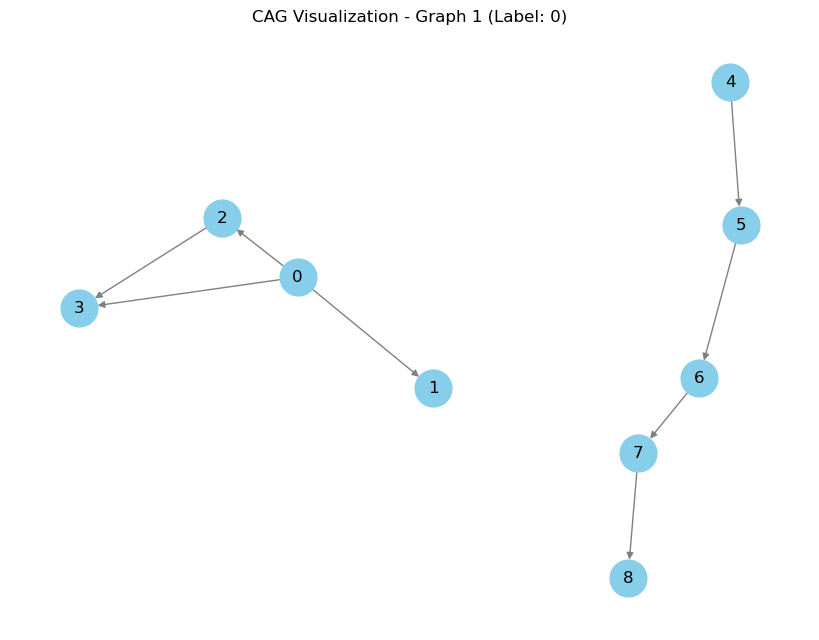

Visualizing Graph 2 with label: 0


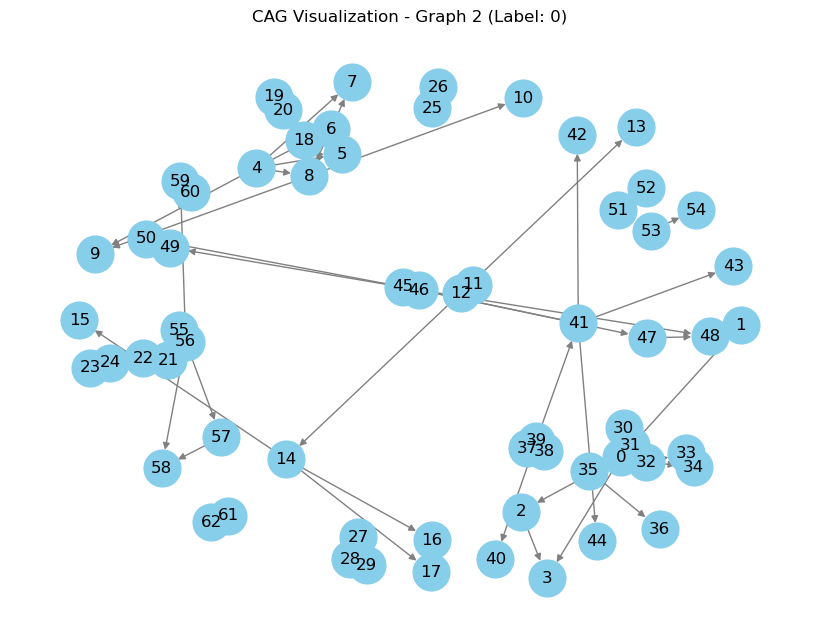

Visualizing Graph 3 with label: 0


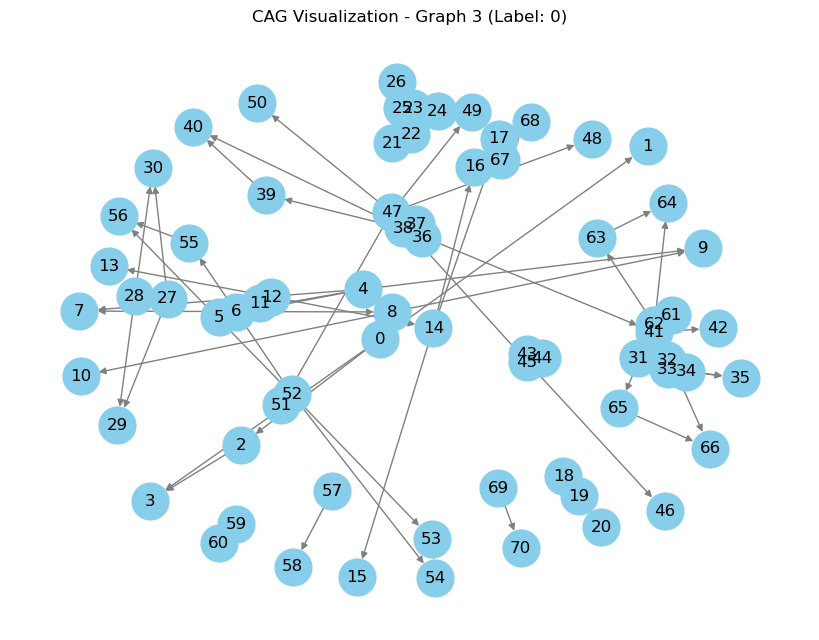

In [21]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data

# 2. Select a few Data objects for visualization
num_graphs_to_visualize = 3
selected_graphs = graph_data_list[:num_graphs_to_visualize]

# 3. For each selected Data object
for i, data in enumerate(selected_graphs):
    print(f"Visualizing Graph {i+1} with label: {int(data.y.item())}")

    # a. Create a NetworkX directed graph
    # Remember to transpose data.edge_index and convert to list of tuples
    nx_graph = nx.DiGraph()
    edge_list = data.edge_index.t().tolist()
    nx_graph.add_edges_from(edge_list)

    # b. Use nx.draw() to visualize the graph
    plt.figure(figsize=(8, 6)) # Adjust figure size as needed
    nx.draw(nx_graph, with_labels=True, node_color='skyblue', node_size=700, edge_color='gray', arrows=True)

    # c. Add a title to the plot
    plt.title(f"CAG Visualization - Graph {i+1} (Label: {int(data.y.item())})")

    # d. Display the plot
    plt.show()
